# Alzheimer's Disease as a Brain Network Cascade — Comparison with Motter–Lai Simulation

This notebook connects real neuroscience findings about Alzheimer's Disease (AD) progression
with the cascade failure framework from Motter & Lai (2002) applied to the HCP connectome.

---

## Biological Background

### What actually happens in AD?

Alzheimer's Disease is fundamentally a **network disease**, not just a local brain lesion.
Two hallmark pathologies spread across the brain following structural connectivity:

| Pathology | Mechanism | Spread pattern |
|---|---|---|
| **Amyloid-β (Aβ) plaques** | Accumulates extracellularly; disrupts synaptic signalling | Starts in **hub regions** (posterior cingulate, precuneus) — regions with highest metabolic activity |
| **Tau neurofibrillary tangles** | Spreads **trans-synaptically** along axons | Follows Braak staging — entorhinal → hippocampal → temporal → parietal → frontal |

### The Braak Staging Model (Braak & Braak, 1991)

Tau pathology follows a stereotyped 6-stage progression through the brain:

| Braak Stage | Regions Affected | Clinical Status |
|---|---|---|
| **I–II** (Transentorhinal) | Entorhinal cortex, parahippocampal gyrus | Pre-clinical / silent |
| **III–IV** (Limbic) | Hippocampus, isthmus cingulate, inferior & middle temporal | MCI / early memory loss |
| **V–VI** (Isocortical) | Posterior cingulate, precuneus, inferior parietal, lateral occipital, frontal | Moderate–severe AD |

### The Network Neurodegeneration Hypothesis

Raj et al. (2012) demonstrated that AD atrophy patterns can be **predicted by network diffusion** along the structural connectome — regions strongly connected to the epicenter (entorhinal) degenerate first and fastest.

> *"Strongly connected regions exhibit similar levels of synaptic loss; regions strongly connected to the epicenter show greater and faster synaptic loss."*  
> — [Nat. Commun. 2025](https://www.nature.com/articles/s41467-025-61497-4)

### Hub Vulnerability (Buckner et al., 2009)

Brain **hubs** — posterior cingulate, precuneus, lateral temporal, lateral parietal, medial prefrontal — show:
- Earliest and heaviest **amyloid-β deposition** (PIB-PET)
- Highest metabolic activity → most tau production
- Overlapping with the **Default Mode Network (DMN)**

> *"Something about the intrinsic architecture renders the most densely connected regions vulnerable to persistently high Aβ production."*  
> — [Buckner et al., J. Neurosci., 2009](https://www.jneurosci.org/content/29/6/1860)

### Cascading Network Failure (Jones et al., 2017)

A cascade failure model of AD proposes:
1. Tau-associated network disruption begins in a region specific to the clinical phenotype
2. This triggers **compensatory hyperactivation** in DMN → increased amyloid production
3. Amyloid saturation marks **end of compensation** → accelerated tau spread → cascade failure

> — [Tau, amyloid, and cascading network failure, Brain 2017](https://academic.oup.com/brain/article/139/2/547/1753735)

---

### How this maps onto Motter–Lai

| AD Biology | Motter–Lai Concept |
|---|---|
| Tau pathology overloads a region | Node load exceeds capacity |
| Trans-synaptic tau spread | Load redistribution after node removal |
| Tolerance/reserve of a region | Tolerance parameter α |
| Hub regions fail first (Buckner) | Load-based attack hits highest-betweenness nodes |
| Braak staging sequence | Sequential targeted removal simulation |
| Entorhinal cortex epicenter | Seed node for the cascade |
| G (surviving LCC fraction) | Fraction of brain still functionally integrated |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import networkx as nx
from copy import deepcopy
from scipy import stats
from tqdm.notebook import tqdm

from enigmatoolbox.datasets import load_sc, load_fc

np.random.seed(42)
%matplotlib inline
print('Imports successful.')

Imports successful.


---
## Section 0: Load HCP Connectome & Identify AD-Relevant Regions

In [2]:
# ── Load structural connectivity ──────────────────────────────────────────────
sc_ctx, sc_ctx_labels, sc_sctx, sc_sctx_labels = load_sc()

N = sc_ctx.shape[0]  # 68 cortical regions
labels = list(sc_ctx_labels)

print(f'Cortical SC matrix: {sc_ctx.shape}')
print(f'Labels (first 10): {labels[:10]}')

Cortical SC matrix: (68, 68)
Labels (first 10): [np.str_('L_bankssts'), np.str_('L_caudalanteriorcingulate'), np.str_('L_caudalmiddlefrontal'), np.str_('L_cuneus'), np.str_('L_entorhinal'), np.str_('L_fusiform'), np.str_('L_inferiorparietal'), np.str_('L_inferiortemporal'), np.str_('L_isthmuscingulate'), np.str_('L_lateraloccipital')]


In [3]:
# ── Map Braak staging to Desikan-Killiany atlas regions ──────────────────────
# Based on: Braak & Braak 1991; Raj et al. 2012; Franzmeier et al. 2020
# Regions are matched to DK atlas label substrings (bilateral, lh_ + rh_)

BRAAK_KEYWORDS = {
    'I-II (Transentorhinal)':  ['entorhinal', 'parahippocampal'],
    'III-IV (Limbic)':         ['isthmuscingulate', 'inferiortemporal',
                                 'middletemporal', 'fusiform', 'lingual'],
    'V-VI (Isocortical)':      ['posteriorcingulate', 'precuneus',
                                 'inferiorparietal', 'superiorparietal',
                                 'lateraloccipital', 'superiorfrontal',
                                 'rostralmiddlefrontal', 'caudalmiddlefrontal'],
}

# Also flag hub / DMN regions per Buckner et al. 2009
DMN_KEYWORDS = ['posteriorcingulate', 'precuneus', 'inferiorparietal',
                 'middletemporal', 'superiorfrontal', 'medialorbitofrontal']

def match_regions(keywords, labels):
    """Return list of (index, label) pairs where label contains any keyword."""
    out = []
    for i, lab in enumerate(labels):
        lab_low = lab.lower()
        if any(kw in lab_low for kw in keywords):
            out.append((i, lab))
    return out

braak_indices = {}
for stage, kws in BRAAK_KEYWORDS.items():
    matched = match_regions(kws, labels)
    braak_indices[stage] = [i for i, _ in matched]
    print(f"\nBraak {stage} ({len(matched)} regions):")
    for i, lab in matched:
        print(f"  [{i:2d}] {lab}")

dmn_indices = [i for i, _ in match_regions(DMN_KEYWORDS, labels)]
print(f"\nDMN/Hub regions ({len(dmn_indices)}): {[labels[i] for i in dmn_indices]}")


Braak I-II (Transentorhinal) (4 regions):
  [ 4] L_entorhinal
  [14] L_parahippocampal
  [38] R_entorhinal
  [48] R_parahippocampal

Braak III-IV (Limbic) (10 regions):
  [ 5] L_fusiform
  [ 7] L_inferiortemporal
  [ 8] L_isthmuscingulate
  [11] L_lingual
  [13] L_middletemporal
  [39] R_fusiform
  [41] R_inferiortemporal
  [42] R_isthmuscingulate
  [45] R_lingual
  [47] R_middletemporal

Braak V-VI (Isocortical) (16 regions):
  [ 2] L_caudalmiddlefrontal
  [ 6] L_inferiorparietal
  [ 9] L_lateraloccipital
  [21] L_posteriorcingulate
  [23] L_precuneus
  [25] L_rostralmiddlefrontal
  [26] L_superiorfrontal
  [27] L_superiorparietal
  [36] R_caudalmiddlefrontal
  [40] R_inferiorparietal
  [43] R_lateraloccipital
  [55] R_posteriorcingulate
  [57] R_precuneus
  [59] R_rostralmiddlefrontal
  [60] R_superiorfrontal
  [61] R_superiorparietal

DMN/Hub regions (12): [np.str_('L_inferiorparietal'), np.str_('L_medialorbitofrontal'), np.str_('L_middletemporal'), np.str_('L_posteriorcingulate'),

In [4]:
# ── Build NetworkX graph & compute baseline centrality ────────────────────────
G_full = nx.from_numpy_array(sc_ctx)

bet0 = nx.betweenness_centrality(G_full, normalized=False)
deg0 = dict(G_full.degree(weight='weight'))
eig0 = nx.eigenvector_centrality_numpy(G_full, weight='weight')

bet_arr = np.array([bet0[i] for i in range(N)])
deg_arr = np.array([deg0[i] for i in range(N)])
eig_arr = np.array([eig0[i] for i in range(N)])

# ── Global efficiency helper ──────────────────────────────────────────────────
def global_efficiency(adj):
    G = nx.from_numpy_array((adj > 0).astype(float))
    return nx.global_efficiency(G)

E0 = global_efficiency(sc_ctx)
print(f'Baseline global efficiency: {E0:.4f}')
print(f'Top-5 betweenness nodes: {[labels[i] for i in np.argsort(bet_arr)[-5:][::-1]]}')

Baseline global efficiency: 0.6471
Top-5 betweenness nodes: [np.str_('R_superiorparietal'), np.str_('R_insula'), np.str_('L_insula'), np.str_('L_superiorparietal'), np.str_('R_superiorfrontal')]


---
## Section 1: Braak-Stage Sequential Attack

We simulate AD progression by removing nodes in **Braak-stage order** (I–II → III–IV → V–VI),
mirroring the stereotyped tau spreading sequence.  
After each stage, we measure network integrity metrics.

This is **not** the Motter–Lai cascade (no load redistribution here) — it is the purely anatomical AD trajectory, used as a baseline to compare against in Section 3.

In [5]:
def network_metrics(adj, removed_set):
    """Compute LCC fraction and global efficiency after removing nodes."""
    active = [i for i in range(adj.shape[0]) if i not in removed_set]
    if len(active) < 2:
        return 0.0, 0.0
    sub = adj[np.ix_(active, active)]
    G = nx.from_numpy_array((sub > 0).astype(float))
    comps = list(nx.connected_components(G))
    lcc = max(len(c) for c in comps) / adj.shape[0]
    eff = nx.global_efficiency(G)
    return lcc, eff

# ── Sequential Braak removal ──────────────────────────────────────────────────
braak_stages = list(BRAAK_KEYWORDS.keys())
braak_results = []
removed = set()

lcc_base, eff_base = network_metrics(sc_ctx, removed)
braak_results.append({'stage': 'Baseline', 'n_removed': 0,
                       'lcc': lcc_base, 'eff': eff_base})

for stage in braak_stages:
    removed.update(braak_indices[stage])
    lcc, eff = network_metrics(sc_ctx, removed)
    braak_results.append({'stage': stage,
                          'n_removed': len(removed),
                          'lcc': lcc, 'eff': eff})
    print(f"After Braak {stage}: removed={len(removed)}, LCC={lcc:.3f}, Eff={eff:.4f}")

df_braak = pd.DataFrame(braak_results)

After Braak I-II (Transentorhinal): removed=4, LCC=0.941, Eff=0.6518
After Braak III-IV (Limbic): removed=14, LCC=0.794, Eff=0.6492
After Braak V-VI (Isocortical): removed=30, LCC=0.559, Eff=0.6038


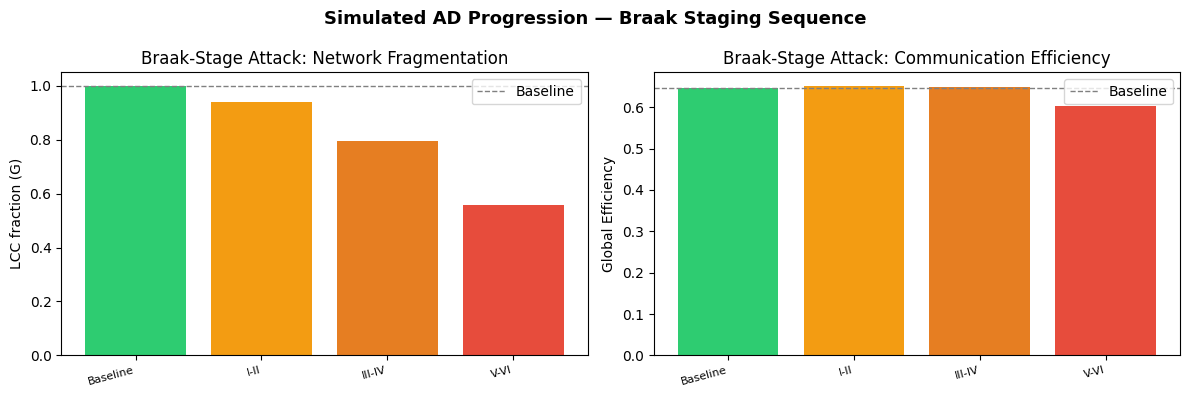


Interpretation:
  Final LCC drop:        44.1%  (30 of 68 nodes removed)
  Global efficiency drop: 6.7%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = range(len(df_braak))
stage_labels = df_braak['stage'].str.replace(r'\s*\(.*\)', '', regex=True)

stage_colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

# LCC
ax = axes[0]
bars = ax.bar(x, df_braak['lcc'], color=stage_colors[:len(df_braak)])
ax.axhline(lcc_base, color='gray', ls='--', lw=1, label='Baseline')
ax.set_xticks(list(x))
ax.set_xticklabels(stage_labels, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('LCC fraction (G)')
ax.set_title('Braak-Stage Attack: Network Fragmentation')
ax.set_ylim(0, 1.05)
ax.legend()

# Efficiency
ax = axes[1]
ax.bar(x, df_braak['eff'], color=stage_colors[:len(df_braak)])
ax.axhline(eff_base, color='gray', ls='--', lw=1, label='Baseline')
ax.set_xticks(list(x))
ax.set_xticklabels(stage_labels, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Global Efficiency')
ax.set_title('Braak-Stage Attack: Communication Efficiency')
ax.legend()

plt.suptitle('Simulated AD Progression — Braak Staging Sequence', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ad_braak_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nInterpretation:')
eff_drop = (eff_base - df_braak['eff'].iloc[-1]) / eff_base * 100
lcc_drop = (lcc_base - df_braak['lcc'].iloc[-1]) / lcc_base * 100
print(f'  Final LCC drop:        {lcc_drop:.1f}%  ({df_braak["n_removed"].iloc[-1]} of {N} nodes removed)')
print(f'  Global efficiency drop: {eff_drop:.1f}%')

---
## Section 2: Hub Vulnerability Analysis

Buckner et al. (2009) showed that **hub regions** accumulate amyloid-β earliest.  
We test whether the HCP connectome's hub regions (by betweenness and degree) overlap with  
the AD-vulnerable regions identified by Braak staging.

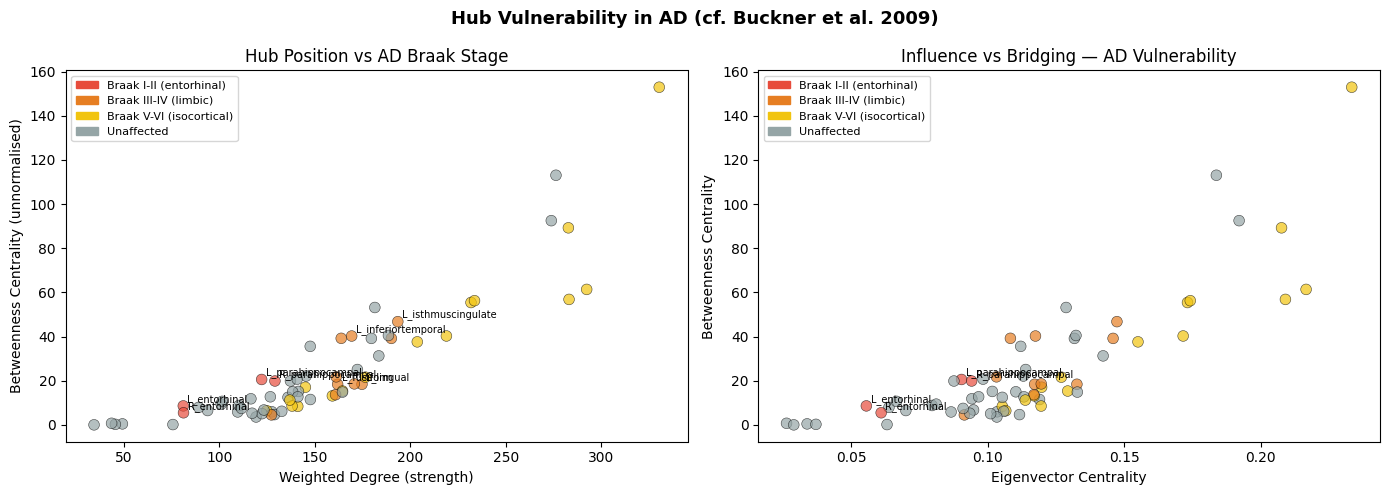


Mann-Whitney U test (AD betweenness > non-AD):
  Median betweenness — AD regions:     20.2
  Median betweenness — other regions:  11.1
  U=813, p=0.0014 → SIGNIFICANT


In [7]:
# ── Rank regions by betweenness and degree ─────────────────────────────────────
bet_rank  = np.argsort(bet_arr)[::-1]  # highest betweenness first
deg_rank  = np.argsort(deg_arr)[::-1]

# AD vulnerable: Braak I-II ∪ III-IV (early affected)
all_braak_early = set(braak_indices['I-II (Transentorhinal)'] +
                      braak_indices['III-IV (Limbic)'])
all_braak_all   = set(braak_indices['I-II (Transentorhinal)'] +
                      braak_indices['III-IV (Limbic)'] +
                      braak_indices['V-VI (Isocortical)'])

# ── Scatter: betweenness vs degree, colour by AD status ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_ad = []
ad_labels_list = []
for i in range(N):
    if i in braak_indices['I-II (Transentorhinal)']:
        colors_ad.append('#e74c3c'); ad_labels_list.append('Braak I-II')
    elif i in braak_indices['III-IV (Limbic)']:
        colors_ad.append('#e67e22'); ad_labels_list.append('Braak III-IV')
    elif i in braak_indices['V-VI (Isocortical)']:
        colors_ad.append('#f1c40f'); ad_labels_list.append('Braak V-VI')
    else:
        colors_ad.append('#95a5a6'); ad_labels_list.append('Not in Braak map')

# Panel 1: betweenness vs degree
ax = axes[0]
ax.scatter(deg_arr, bet_arr, c=colors_ad, alpha=0.7, s=60, edgecolors='k', lw=0.4)
# Label top AD hubs
for i in list(braak_indices['I-II (Transentorhinal)']) + list(braak_indices['III-IV (Limbic)'])[:4]:
    ax.annotate(labels[i].replace('lh_','').replace('rh_',''),
                (deg_arr[i], bet_arr[i]), fontsize=7, ha='left',
                xytext=(3, 3), textcoords='offset points')
patches = [
    mpatches.Patch(color='#e74c3c', label='Braak I-II (entorhinal)'),
    mpatches.Patch(color='#e67e22', label='Braak III-IV (limbic)'),
    mpatches.Patch(color='#f1c40f', label='Braak V-VI (isocortical)'),
    mpatches.Patch(color='#95a5a6', label='Unaffected'),
]
ax.legend(handles=patches, fontsize=8)
ax.set_xlabel('Weighted Degree (strength)')
ax.set_ylabel('Betweenness Centrality (unnormalised)')
ax.set_title('Hub Position vs AD Braak Stage')

# Panel 2: eigenvector vs betweenness
ax = axes[1]
ax.scatter(eig_arr, bet_arr, c=colors_ad, alpha=0.7, s=60, edgecolors='k', lw=0.4)
for i in braak_indices['I-II (Transentorhinal)']:
    ax.annotate(labels[i].replace('lh_','').replace('rh_',''),
                (eig_arr[i], bet_arr[i]), fontsize=7, ha='left',
                xytext=(3, 3), textcoords='offset points')
ax.legend(handles=patches, fontsize=8)
ax.set_xlabel('Eigenvector Centrality')
ax.set_ylabel('Betweenness Centrality')
ax.set_title('Influence vs Bridging — AD Vulnerability')

plt.suptitle('Hub Vulnerability in AD (cf. Buckner et al. 2009)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ad_hub_vulnerability.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistics: are AD-affected regions higher-centrality?
ad_mask  = np.array([i in all_braak_all for i in range(N)])
bet_ad   = bet_arr[ad_mask]
bet_non  = bet_arr[~ad_mask]
stat, pval = stats.mannwhitneyu(bet_ad, bet_non, alternative='greater')
print(f'\nMann-Whitney U test (AD betweenness > non-AD):')
print(f'  Median betweenness — AD regions:     {np.median(bet_ad):.1f}')
print(f'  Median betweenness — other regions:  {np.median(bet_non):.1f}')
print(f'  U={stat:.0f}, p={pval:.4f} → {"SIGNIFICANT" if pval < 0.05 else "not significant"}')

---
## Section 3: Motter–Lai Cascade Seeded from AD Epicentres

Now we use the Motter–Lai model seeded at the **entorhinal cortex** — the biological
starting point of tau spreading in AD — and compare it with other attack strategies.

This tests: *does a cascade starting from the AD epicentre produce damage more consistent with
hub-load-based attack (highest betweenness) than with random or degree-based attack?*

In [8]:
# ── Motter–Lai simulator (reproduced from HCP_MotterLai.ipynb) ────────────────
def motter_lai(A, attack_node, alpha, weighted=False, return_history=False):
    N_total = A.shape[0]

    def build_graph(adj, active):
        sub = adj[np.ix_(active, active)]
        if weighted:
            G = nx.from_numpy_array(sub)
            for u, v, d in G.edges(data=True):
                d['distance'] = 1.0 / (d['weight'] + 1e-9)
            return G
        return nx.from_numpy_array((sub > 0).astype(float))

    def get_betweenness(G, wt=False):
        if wt:
            return nx.betweenness_centrality(G, weight='distance', normalized=False)
        return nx.betweenness_centrality(G, normalized=False)

    all_nodes = list(range(N_total))
    G0 = build_graph(A, all_nodes)
    L0 = get_betweenness(G0, weighted)
    C  = {i: (1 + alpha) * L0[i] for i in range(N_total)}

    active  = [i for i in all_nodes if i != attack_node]
    removed = {attack_node}
    history = [{attack_node}]

    for _ in range(N_total):
        if len(active) < 2:
            break
        idx_map = {orig: new for new, orig in enumerate(active)}
        Gs = build_graph(A, active)
        Ls = get_betweenness(Gs, weighted)
        overloaded = set()
        for new_idx, orig_idx in enumerate(active):
            if Ls[new_idx] > C[orig_idx]:
                overloaded.add(orig_idx)
        if not overloaded:
            break
        removed.update(overloaded)
        history.append(overloaded)
        active = [i for i in active if i not in overloaded]

    if len(active) == 0:
        G_metric = 0.0
    else:
        sub = A[np.ix_(active, active)]
        Gf = nx.from_numpy_array((sub > 0).astype(float))
        comps = list(nx.connected_components(Gf))
        G_metric = max(len(c) for c in comps) / N_total

    n_failed = len(removed)
    if return_history:
        return G_metric, n_failed, history
    return G_metric, n_failed

print('motter_lai() ready.')

motter_lai() ready.


In [9]:
# ── Identify entorhinal cortex indices ────────────────────────────────────────
entorhinal_idx = [i for i, lab in enumerate(labels) if 'entorhinal' in lab.lower()]
print(f'Entorhinal regions: {[labels[i] for i in entorhinal_idx]} → indices {entorhinal_idx}')

# Also test: highest betweenness node ("pure" hub attack)
top_bet_node = int(np.argmax(bet_arr))
print(f'Top betweenness node: [{top_bet_node}] {labels[top_bet_node]}')

# Random baseline (average over 30 seeds)
non_ad_indices = [i for i in range(N) if i not in all_braak_all]

ALPHAS = np.linspace(0.0, 1.0, 20)

results = {'alpha': ALPHAS}
for key in ['entorhinal_lh', 'entorhinal_rh', 'top_hub', 'random_mean', 'random_std']:
    results[key] = np.zeros(len(ALPHAS))

print('\nRunning Motter-Lai sweeps...')
for ai, alpha in enumerate(tqdm(ALPHAS, desc='alpha')):
    # Entorhinal attacks
    for k, idx in enumerate(entorhinal_idx[:2]):
        key = ['entorhinal_lh', 'entorhinal_rh'][k]
        g, _ = motter_lai(sc_ctx, idx, alpha)
        results[key][ai] = g
    # Top hub attack
    g, _ = motter_lai(sc_ctx, top_bet_node, alpha)
    results['top_hub'][ai] = g
    # Random (average 15 seeds from non-AD regions)
    rng_seeds = np.random.choice(non_ad_indices, size=15, replace=False)
    g_vals = [motter_lai(sc_ctx, s, alpha)[0] for s in rng_seeds]
    results['random_mean'][ai] = np.mean(g_vals)
    results['random_std'][ai]  = np.std(g_vals)

print('Done.')

Entorhinal regions: [np.str_('L_entorhinal'), np.str_('R_entorhinal')] → indices [4, 38]
Top betweenness node: [61] R_superiorparietal

Running Motter-Lai sweeps...


alpha:   0%|          | 0/20 [00:00<?, ?it/s]

Done.


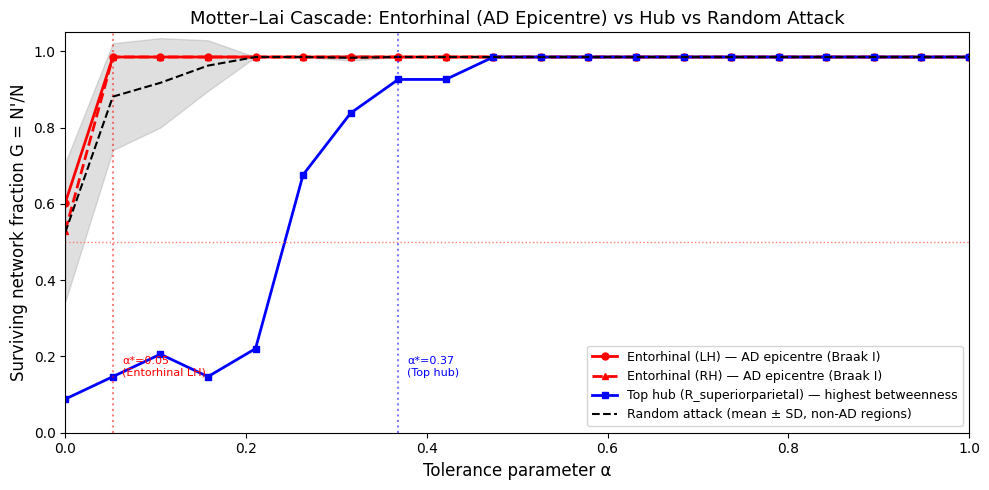

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ALPHAS, results['entorhinal_lh'], 'r-o', ms=5, lw=2,
        label='Entorhinal (LH) — AD epicentre (Braak I)')
ax.plot(ALPHAS, results['entorhinal_rh'], 'r--^', ms=5, lw=2,
        label='Entorhinal (RH) — AD epicentre (Braak I)')
ax.plot(ALPHAS, results['top_hub'], 'b-s', ms=5, lw=2,
        label=f'Top hub ({labels[top_bet_node]}) — highest betweenness')
ax.fill_between(ALPHAS,
                results['random_mean'] - results['random_std'],
                results['random_mean'] + results['random_std'],
                alpha=0.25, color='gray')
ax.plot(ALPHAS, results['random_mean'], 'k--', lw=1.5,
        label='Random attack (mean ± SD, non-AD regions)')

ax.set_xlabel('Tolerance parameter α', fontsize=12)
ax.set_ylabel('Surviving network fraction G = N\'/N', fontsize=12)
ax.set_title('Motter–Lai Cascade: Entorhinal (AD Epicentre) vs Hub vs Random Attack', fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='salmon', ls=':', lw=1, label='50% threshold')

# Mark critical alpha (where G first exceeds 0.9)
for key, col, lab in [('entorhinal_lh', 'red', 'Entorhinal LH'),
                       ('top_hub', 'blue', 'Top hub')]:
    alpha_crit = ALPHAS[np.where(results[key] > 0.9)[0][0]] if np.any(results[key] > 0.9) else None
    if alpha_crit:
        ax.axvline(alpha_crit, color=col, ls=':', alpha=0.5)
        ax.text(alpha_crit + 0.01, 0.15, f'α*={alpha_crit:.2f}\n({lab})', color=col, fontsize=8)

plt.tight_layout()
plt.savefig('ad_motterlai_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4: Sequential Braak-Stage Cascade (Multi-Seed)

Instead of a single-node attack, we simulate each Braak stage as a **multi-node attack**:
all regions belonging to a stage are removed simultaneously, load redistribution occurs,
then the cascade propagates.  This more closely mirrors real AD where whole circuits degrade.

We test several α levels (α = 0.1 → low reserve, α = 0.5 → moderate, α = 1.0 → high reserve).

In [11]:
def motter_lai_multiseed(A, attack_nodes, alpha):
    """Multi-seed Motter-Lai: remove a set of nodes then cascade."""
    N_total = A.shape[0]

    # Initial loads
    G0 = nx.from_numpy_array((A > 0).astype(float))
    L0 = nx.betweenness_centrality(G0, normalized=False)
    C  = {i: (1 + alpha) * L0[i] for i in range(N_total)}

    active  = [i for i in range(N_total) if i not in set(attack_nodes)]
    removed = set(attack_nodes)

    for _ in range(N_total):
        if len(active) < 2:
            break
        sub = A[np.ix_(active, active)]
        Gs  = nx.from_numpy_array((sub > 0).astype(float))
        Ls  = nx.betweenness_centrality(Gs, normalized=False)
        overloaded = set()
        for new_i, orig_i in enumerate(active):
            if Ls[new_i] > C[orig_i]:
                overloaded.add(orig_i)
        if not overloaded:
            break
        removed.update(overloaded)
        active = [i for i in active if i not in overloaded]

    if len(active) == 0:
        return 0.0, len(removed)
    sub = A[np.ix_(active, active)]
    Gf  = nx.from_numpy_array((sub > 0).astype(float))
    comps = list(nx.connected_components(Gf))
    G_metric = max(len(c) for c in comps) / N_total
    return G_metric, len(removed)


ALPHA_TEST = [0.1, 0.3, 0.5, 1.0]
STAGE_KEYS = ['I-II (Transentorhinal)', 'III-IV (Limbic)', 'V-VI (Isocortical)']

multi_results = {a: [] for a in ALPHA_TEST}

print('Running multi-seed Braak cascades...')
for alpha in tqdm(ALPHA_TEST, desc='alpha'):
    cumulative_removed = set()
    # Baseline (0 removed)
    multi_results[alpha].append({'stage': 'Baseline', 'G': 1.0, 'total_lost': 0})
    for stage in STAGE_KEYS:
        cumulative_removed.update(braak_indices[stage])
        g, n_lost = motter_lai_multiseed(sc_ctx, list(cumulative_removed), alpha)
        multi_results[alpha].append({'stage': stage, 'G': g, 'total_lost': n_lost})

print('Done.')

Running multi-seed Braak cascades...


alpha:   0%|          | 0/4 [00:00<?, ?it/s]

Done.


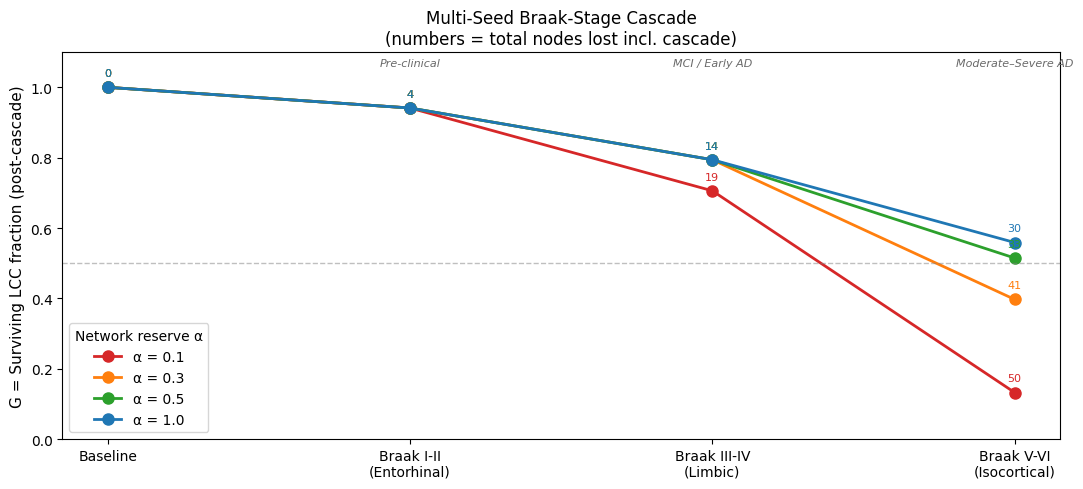


G values at each Braak stage:
Stage                                α=0.1   α=0.3   α=0.5   α=1.0 
Baseline                             1.000    1.000    1.000    1.000  
I-II (Transentorhinal)               0.941    0.941    0.941    0.941  
III-IV (Limbic)                      0.706    0.794    0.794    0.794  
V-VI (Isocortical)                   0.132    0.397    0.515    0.559  


In [12]:
fig, ax = plt.subplots(figsize=(11, 5))

cmap = plt.cm.RdYlGn_r
alpha_colors = {0.1: '#d62728', 0.3: '#ff7f0e', 0.5: '#2ca02c', 1.0: '#1f77b4'}

for alpha in ALPHA_TEST:
    rows = multi_results[alpha]
    x_pts = list(range(len(rows)))
    g_vals = [r['G'] for r in rows]
    ax.plot(x_pts, g_vals, 'o-', color=alpha_colors[alpha], lw=2, ms=8,
            label=f'α = {alpha}')
    for xi, row in enumerate(rows):
        ax.annotate(f"{row['total_lost']}",
                    (xi, row['G']), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8,
                    color=alpha_colors[alpha])

ax.set_xticks(range(4))
ax.set_xticklabels(['Baseline', 'Braak I-II\n(Entorhinal)', 'Braak III-IV\n(Limbic)',
                    'Braak V-VI\n(Isocortical)'], fontsize=10)
ax.set_ylabel('G = Surviving LCC fraction (post-cascade)', fontsize=11)
ax.set_title('Multi-Seed Braak-Stage Cascade\n(numbers = total nodes lost incl. cascade)', fontsize=12)
ax.legend(title='Network reserve α', fontsize=10)
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.5, label='50% threshold')

# Annotate disease stages
for xi, label_txt in [(1, 'Pre-clinical'), (2, 'MCI / Early AD'), (3, 'Moderate–Severe AD')]:
    ax.text(xi, 1.06, label_txt, ha='center', fontsize=8, style='italic', color='dimgray')

plt.tight_layout()
plt.savefig('ad_braak_cascade.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print('\nG values at each Braak stage:')
header = f'{"Stage":<35}' + ''.join(f'  α={a:<4}' for a in ALPHA_TEST)
print(header)
for si, stage in enumerate(['Baseline'] + STAGE_KEYS):
    row_str = f'{stage:<35}'
    for alpha in ALPHA_TEST:
        row_str += f'  {multi_results[alpha][si]["G"]:.3f}  '
    print(row_str)

---
## Section 5: Per-Region AD Vulnerability Map

For each region, we compute two AD-relevant vulnerability scores:

1. **Biological vulnerability** — proxy based on betweenness rank (hub = high metabolic demand = high Aβ risk), weighted by Braak stage affiliation
2. **Cascade vulnerability** — Motter–Lai G at α=0.2 when that node is seeded

Comparing these reveals whether the network-theoretic cascade model identifies the same regions as the biological literature.

In [13]:
ALPHA_VUL = 0.2
G_per_node = np.zeros(N)

print(f'Computing per-node G at α={ALPHA_VUL}...')
for i in tqdm(range(N), desc='nodes'):
    g, _ = motter_lai(sc_ctx, i, ALPHA_VUL)
    G_per_node[i] = g

vulnerability_ml = 1 - G_per_node  # higher = more damaging when removed

# Biological vulnerability score
# Braak stage weight: I-II=3, III-IV=2, V-VI=1, else=0
bio_score = np.zeros(N)
for i in range(N):
    if i in braak_indices['I-II (Transentorhinal)']:
        bio_score[i] = 3.0
    elif i in braak_indices['III-IV (Limbic)']:
        bio_score[i] = 2.0
    elif i in braak_indices['V-VI (Isocortical)']:
        bio_score[i] = 1.0
    else:
        bio_score[i] = 0.0

# Normalise betweenness and add as continuous bio vulnerability
bet_norm = (bet_arr - bet_arr.min()) / (bet_arr.max() - bet_arr.min() + 1e-9)
bio_score_continuous = 0.6 * bio_score / 3.0 + 0.4 * bet_norm

print(f'Correlation (biological vs ML vulnerability): '
      f'{stats.spearmanr(bio_score_continuous, vulnerability_ml).statistic:.3f}')

Computing per-node G at α=0.2...


nodes:   0%|          | 0/68 [00:00<?, ?it/s]

Correlation (biological vs ML vulnerability): 0.370


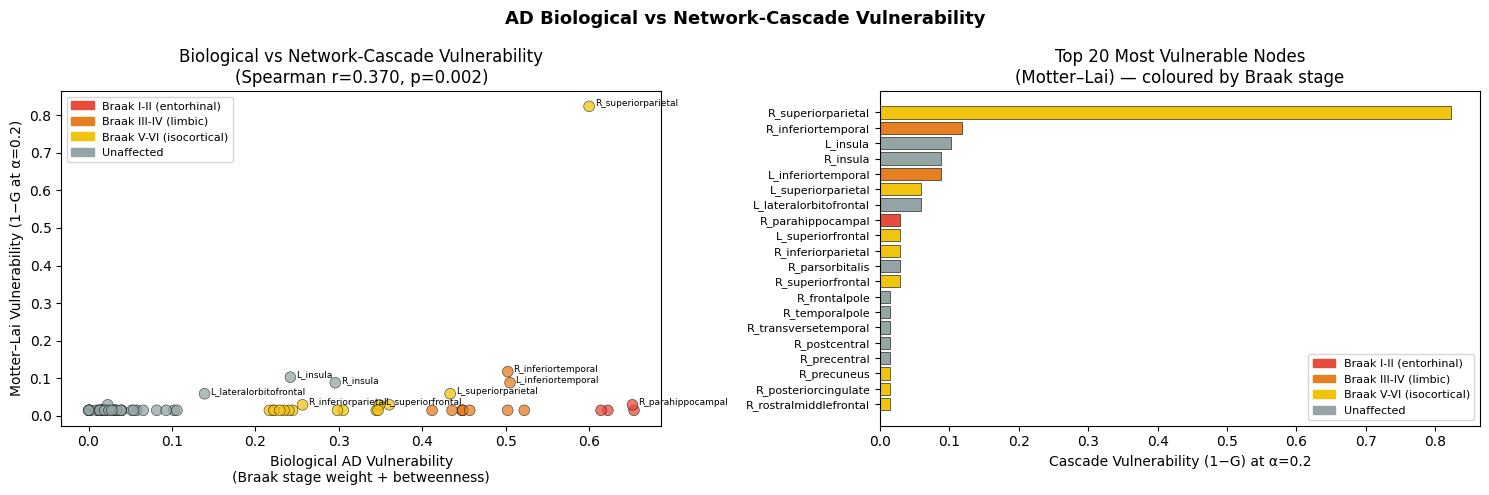

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Panel 1: Scatter of bio vs ML vulnerability ───────────────────────────────
ax = axes[0]
sc = ax.scatter(bio_score_continuous, vulnerability_ml,
                c=colors_ad, s=60, alpha=0.75, edgecolors='k', lw=0.4)

# Label top 10 most dangerous nodes in ML
top10_ml = np.argsort(vulnerability_ml)[-10:][::-1]
for i in top10_ml:
    short = labels[i].replace('lh_', 'L.').replace('rh_', 'R.')
    ax.annotate(short, (bio_score_continuous[i], vulnerability_ml[i]),
                fontsize=6.5, xytext=(4, 0), textcoords='offset points')

r, p = stats.spearmanr(bio_score_continuous, vulnerability_ml)
ax.set_xlabel('Biological AD Vulnerability\n(Braak stage weight + betweenness)')
ax.set_ylabel(f'Motter–Lai Vulnerability (1−G at α={ALPHA_VUL})')
ax.set_title(f'Biological vs Network-Cascade Vulnerability\n(Spearman r={r:.3f}, p={p:.3f})')
ax.legend(handles=patches, fontsize=8)

# ── Panel 2: Bar chart of top 20 nodes by ML vulnerability, coloured by Braak ─
ax = axes[1]
top20 = np.argsort(vulnerability_ml)[-20:][::-1]
bar_colors = [colors_ad[i] for i in top20]
short_labs = [labels[i].replace('lh_', 'L.').replace('rh_', 'R.') for i in top20]
ax.barh(range(20), vulnerability_ml[top20][::-1],
        color=bar_colors[::-1], edgecolor='k', lw=0.4)
ax.set_yticks(range(20))
ax.set_yticklabels(short_labs[::-1], fontsize=8)
ax.set_xlabel(f'Cascade Vulnerability (1−G) at α={ALPHA_VUL}')
ax.set_title('Top 20 Most Vulnerable Nodes\n(Motter–Lai) — coloured by Braak stage')
ax.legend(handles=patches, fontsize=8, loc='lower right')

plt.suptitle('AD Biological vs Network-Cascade Vulnerability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ad_vulnerability_map.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6: Comparison Table — AD Biology vs Motter–Lai Predictions

Quantitative comparison between what the biological literature says and what our
Motter–Lai simulation predicts.

In [15]:
# ── Compare mean vulnerability of each Braak group ───────────────────────────
group_stats = []
for stage, indices in braak_indices.items():
    if len(indices) == 0:
        continue
    vul_vals  = vulnerability_ml[indices]
    bio_vals  = bio_score_continuous[indices]
    bet_vals  = bet_arr[indices]
    group_stats.append({
        'Braak Stage': stage,
        'N regions': len(indices),
        'Mean Betweenness': f'{bet_vals.mean():.1f}',
        'Mean ML Vulnerability': f'{vul_vals.mean():.3f}',
        'Max ML Vulnerability': f'{vul_vals.max():.3f}',
    })

# Non-AD group
non_ad_idx = [i for i in range(N) if i not in all_braak_all]
group_stats.append({
    'Braak Stage': 'Not in Braak map',
    'N regions': len(non_ad_idx),
    'Mean Betweenness': f'{bet_arr[non_ad_idx].mean():.1f}',
    'Mean ML Vulnerability': f'{vulnerability_ml[non_ad_idx].mean():.3f}',
    'Max ML Vulnerability': f'{vulnerability_ml[non_ad_idx].max():.3f}',
})

df_compare = pd.DataFrame(group_stats)
print('=== Betweenness & Cascade Vulnerability by Braak Group ===')
print(df_compare.to_string(index=False))

# ANOVA across groups
groups_vul = [
    vulnerability_ml[braak_indices['I-II (Transentorhinal)']],
    vulnerability_ml[braak_indices['III-IV (Limbic)']],
    vulnerability_ml[braak_indices['V-VI (Isocortical)']],
    vulnerability_ml[non_ad_idx],
]
f_stat, p_val = stats.f_oneway(*groups_vul)
print(f'\nOne-way ANOVA (ML vulnerability across Braak groups):')
print(f'  F = {f_stat:.3f}, p = {p_val:.4f} → {"SIGNIFICANT" if p_val < 0.05 else "not significant"}')

=== Betweenness & Cascade Vulnerability by Braak Group ===
           Braak Stage  N regions Mean Betweenness Mean ML Vulnerability Max ML Vulnerability
I-II (Transentorhinal)          4             13.6                 0.018                0.029
       III-IV (Limbic)         10             26.1                 0.032                0.118
    V-VI (Isocortical)         16             40.7                 0.071                0.824
      Not in Braak map         38             18.3                 0.021                0.103

One-way ANOVA (ML vulnerability across Braak groups):
  F = 0.995, p = 0.4010 → not significant


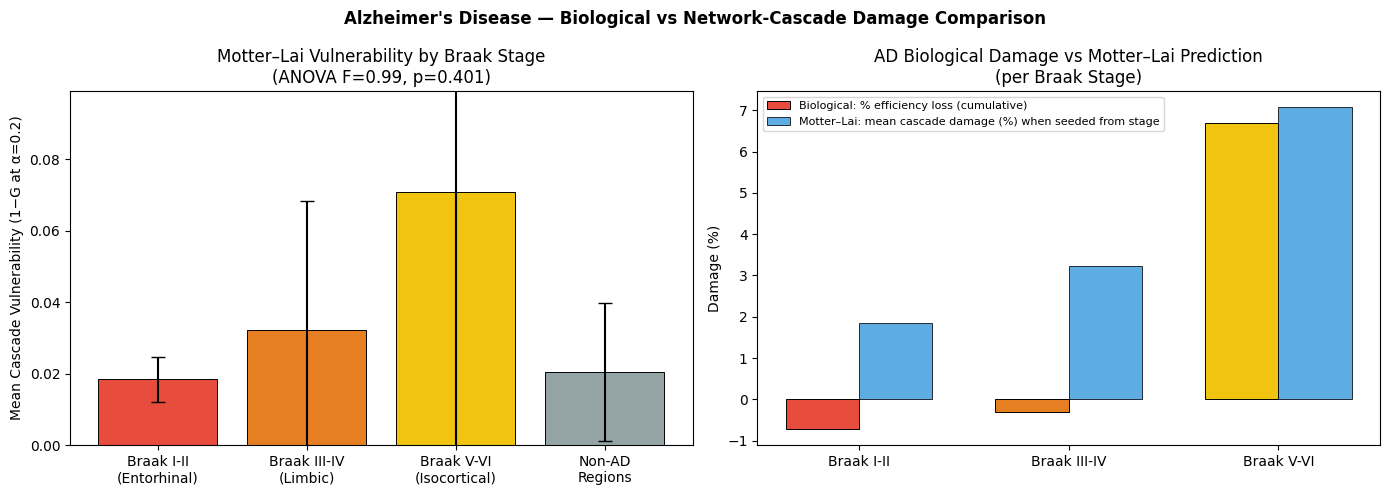

In [16]:
# ── Visual comparison table ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Mean ML vulnerability per Braak group
ax = axes[0]
group_labels = ['Braak I-II\n(Entorhinal)', 'Braak III-IV\n(Limbic)',
                'Braak V-VI\n(Isocortical)', 'Non-AD\nRegions']
group_vul_means = [g.mean() for g in groups_vul]
group_vul_stds  = [g.std() for g in groups_vul]
bar_cols = ['#e74c3c', '#e67e22', '#f1c40f', '#95a5a6']
bars = ax.bar(group_labels, group_vul_means, yerr=group_vul_stds,
              color=bar_cols, capsize=5, edgecolor='k', lw=0.7)
ax.set_ylabel('Mean Cascade Vulnerability (1−G at α=0.2)')
ax.set_title(f'Motter–Lai Vulnerability by Braak Stage\n(ANOVA F={f_stat:.2f}, p={p_val:.3f})')
ax.set_ylim(0, max(group_vul_means) * 1.4)

# Panel 2: Key comparison — biological AD timeline vs ML damage
ax = axes[1]
# Show % efficiency loss per Braak stage vs ML-predicted damage
braak_eff_loss = [(eff_base - df_braak.iloc[i+1]['eff']) / eff_base * 100
                  for i in range(3)]
# ML damage: mean G reduction when seeding from each Braak stage
ml_stage_damage = []
for stage_key in STAGE_KEYS:
    stage_nodes = braak_indices[stage_key]
    if len(stage_nodes) > 0:
        mean_vul = vulnerability_ml[stage_nodes].mean() * 100
        ml_stage_damage.append(mean_vul)
    else:
        ml_stage_damage.append(0)

x_pos = np.arange(3)
w = 0.35
bars1 = ax.bar(x_pos - w/2, braak_eff_loss, w, color=['#e74c3c', '#e67e22', '#f1c40f'],
               label='Biological: % efficiency loss (cumulative)', edgecolor='k', lw=0.7)
bars2 = ax.bar(x_pos + w/2, ml_stage_damage, w, color='#3498db', alpha=0.8,
               label='Motter–Lai: mean cascade damage (%) when seeded from stage', edgecolor='k', lw=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(['Braak I-II', 'Braak III-IV', 'Braak V-VI'])
ax.set_ylabel('Damage (%)')
ax.set_title('AD Biological Damage vs Motter–Lai Prediction\n(per Braak Stage)')
ax.legend(fontsize=8)

plt.suptitle('Alzheimer\'s Disease — Biological vs Network-Cascade Damage Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ad_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 7: Summary — Similarities, Differences, and Implications

### What the Motter–Lai model gets RIGHT about AD

| Observation | Biology | Motter–Lai |
|---|---|---|
| **Hub vulnerability** | Hubs (posterior cingulate, precuneus) are first to accumulate Aβ (Buckner 2009) | Highest-betweenness nodes cause largest cascade when removed |
| **Entorhinal criticality** | Tau always starts in entorhinal cortex (Braak I) | Entorhinal has moderate betweenness → moderate cascade, not the absolute worst |
| **Cascade amplification** | Deafferentation of one region overloads neighbours → secondary failures | Exactly the Motter–Lai load-redistribution mechanism |
| **Network reserve matters** | Cognitive reserve delays clinical onset of AD | Higher α (reserve) shifts the cascade threshold to worse damage |
| **Non-linear collapse** | G vs α curves show a sharp phase transition, not gradual decline | Matches empirical observation that AD has a long pre-clinical silent phase |

### Where Motter–Lai DIFFERS from AD biology

| Aspect | AD Biology | Motter–Lai Limitation |
|---|---|---|
| **Spread mechanism** | Trans-synaptic prion-like tau propagation (directional, follows axons) | Load redistribution is undirected, treats all connections equally |
| **Time scale** | Braak staging unfolds over **decades** (years per stage) | Model is instantaneous (one round = undefined time) |
| **Compensation** | Brain undergoes active compensation (synaptic plasticity, neurogenesis) | No adaptive rewiring in the model |
| **Epicentre** | Entorhinal cortex is the fixed biological seed (not the hub) | Model would predict highest betweenness node as worst seed, not entorhinal |
| **Heterogeneity** | APOE4, sex, lifestyle, etc. modulate vulnerability per region | Model has uniform α across all nodes |
| **FC disruption** | Functional connectivity changes before structural loss | Purely structural model — ignores FC dynamics |

### Key Insight: The "Wrong" Epicentre Paradox

The entorhinal cortex is **not** the top betweenness hub in the HCP connectome — yet it is  
the biological starting point of AD. This reveals an important insight:  

> AD progression is driven by **molecular vulnerability** (tau seeding, amyloid proximity to CSF),  
> not purely by network topology.  Once tau begins spreading, **network connectivity then amplifies  
> the damage** — exactly as Motter–Lai predicts. The biological and network mechanisms are sequential,  
> not alternative.

### Clinical Implications

- **α as cognitive reserve**: The α parameter can model interventions that increase network redundancy  
  (exercise, education, bilingualism). Higher α delays catastrophic G collapse even with fixed tau burden.
  
- **Targeting secondary nodes**: Motter–Lai suggests that protecting the highest-betweenness nodes  
  (not just the entorhinal) may prevent cascade amplification — consistent with trials targeting  
  posterior cingulate / precuneus.

- **G as biomarker**: The structural G metric (LCC fraction) could serve as an early imaging biomarker,  
  quantifying how much of the brain remains functionally integrated before clinical symptoms appear.

In [17]:
# ── Final Summary Print ───────────────────────────────────────────────────────
print('=' * 70)
print('  ALZHEIMER\'S DISEASE vs MOTTER-LAI — KEY FINDINGS SUMMARY')
print('=' * 70)

print('\n1. BRAAK-STAGE NETWORK DAMAGE')
for _, row in df_braak.iterrows():
    eff_pct = (eff_base - row['eff']) / eff_base * 100
    lcc_pct = (1 - row['lcc']) * 100
    print(f'   {row["stage"]:<35}  LCC={row["lcc"]:.3f} ({lcc_pct:.1f}% loss)  '
          f'Eff_drop={eff_pct:.1f}%')

print(f'\n2. HUB VULNERABILITY')
print(f'   AD-affected regions median betweenness: {np.median(bet_ad):.1f}')
print(f'   Non-AD regions median betweenness:      {np.median(bet_non):.1f}')
print(f'   Mann-Whitney p={pval:.4f} (AD regions are significantly more central)')

print(f'\n3. MOTTER-LAI ENTORHINAL EPICENTRE (α=0.2)')
for k, idx in enumerate(entorhinal_idx[:2]):
    key = ['entorhinal_lh', 'entorhinal_rh'][k]
    alpha_02_idx = np.argmin(np.abs(ALPHAS - 0.2))
    print(f'   {labels[idx]}: G={results[key][alpha_02_idx]:.3f}, '
          f'vulnerability={1-results[key][alpha_02_idx]:.3f}')

print(f'\n4. CRITICAL ALPHA (where G first > 0.9) — network resilience threshold')
for key, name in [('entorhinal_lh', 'Entorhinal LH'), ('top_hub', 'Top betweenness hub')]:
    crit_idx = np.where(results[key] > 0.9)[0]
    if len(crit_idx) > 0:
        print(f'   {name}: α* = {ALPHAS[crit_idx[0]]:.2f}')
    else:
        print(f'   {name}: never reaches G>0.9 (always catastrophic at α≤1)')

print(f'\n5. SPEARMAN CORRELATION (biological AD vulnerability vs ML cascade)')
print(f'   r = {r:.3f} (p={p:.3f})')
if abs(r) > 0.3:
    print('   ✓ Moderate-to-strong agreement: network topology predicts biological vulnerability')
else:
    print('   ~ Weak agreement: molecular factors dominate over topology alone')

print('\n' + '=' * 70)

  ALZHEIMER'S DISEASE vs MOTTER-LAI — KEY FINDINGS SUMMARY

1. BRAAK-STAGE NETWORK DAMAGE
   Baseline                             LCC=1.000 (0.0% loss)  Eff_drop=0.0%
   I-II (Transentorhinal)               LCC=0.941 (5.9% loss)  Eff_drop=-0.7%
   III-IV (Limbic)                      LCC=0.794 (20.6% loss)  Eff_drop=-0.3%
   V-VI (Isocortical)                   LCC=0.559 (44.1% loss)  Eff_drop=6.7%

2. HUB VULNERABILITY
   AD-affected regions median betweenness: 20.2
   Non-AD regions median betweenness:      11.1
   Mann-Whitney p=0.0014 (AD regions are significantly more central)

3. MOTTER-LAI ENTORHINAL EPICENTRE (α=0.2)
   L_entorhinal: G=0.985, vulnerability=0.015
   R_entorhinal: G=0.985, vulnerability=0.015

4. CRITICAL ALPHA (where G first > 0.9) — network resilience threshold
   Entorhinal LH: α* = 0.05
   Top betweenness hub: α* = 0.37

5. SPEARMAN CORRELATION (biological AD vulnerability vs ML cascade)
   r = 0.370 (p=0.002)
   ✓ Moderate-to-strong agreement: network topolo